In [95]:
# Libraries

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [96]:
data = pd.read_csv('insurance.csv')
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# EDA

In [97]:
data.shape

(1338, 7)

In [98]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [99]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [100]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [101]:
numeric_col = data.select_dtypes(include='number')
numeric_col

,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520
...,...,...,...,...
1333,50,30.970,3,10600.54830
1334,18,31.920,0,2205.98080
1335,18,36.850,0,1629.83350
1336,21,25.800,0,2007.94500


In [102]:
categorical_col = data.select_dtypes(include='string')
categorical_col

,sex,smoker,region
0,female,yes,southwest
1,male,no,southeast
2,male,no,southeast
3,male,no,northwest
4,male,no,northwest
...,...,...,...
1333,male,no,northwest
1334,female,no,northeast
1335,female,no,southeast
1336,female,no,southwest


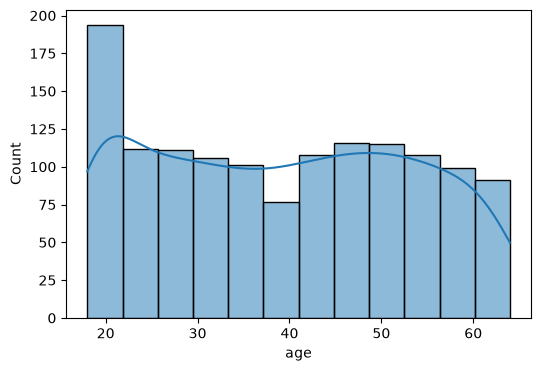

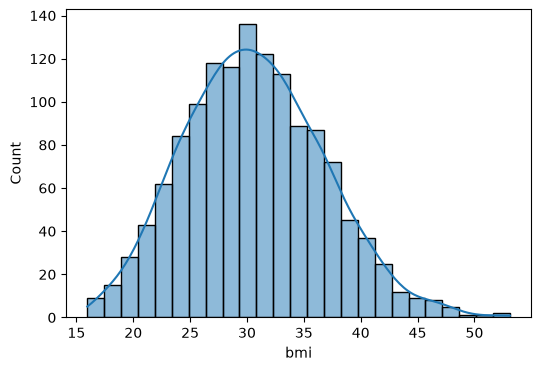

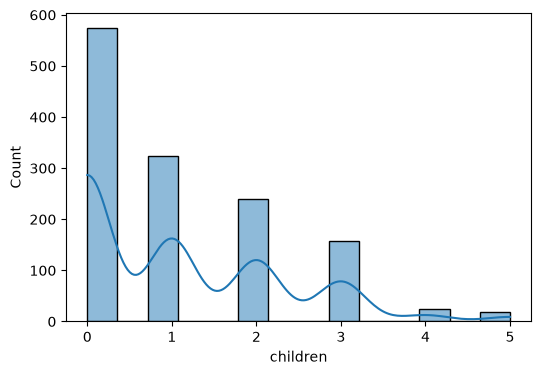

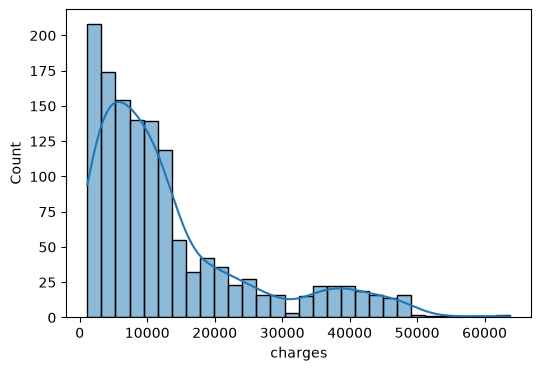

In [103]:
# Plotting Histograms

for col in numeric_col:
    plt.figure(figsize=(6,4))
    sns.histplot(x = data[col], kde= True)

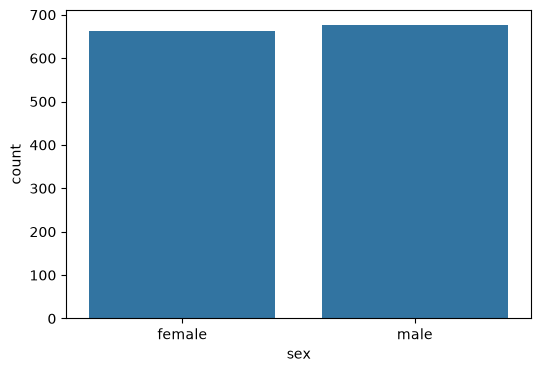

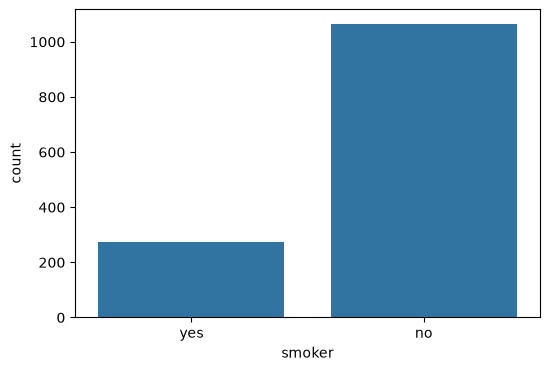

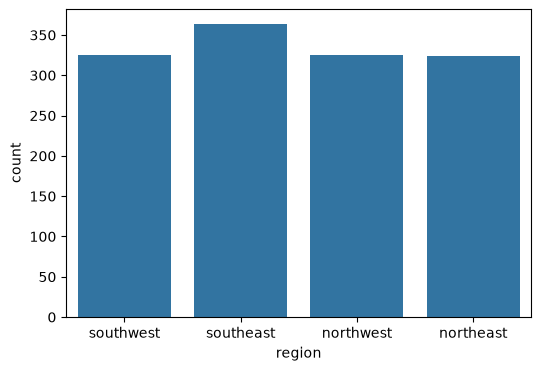

In [104]:
# Plotting Countplot

for col in categorical_col:
    plt.figure(figsize=(6,4))
    sns.countplot(x= data[col])

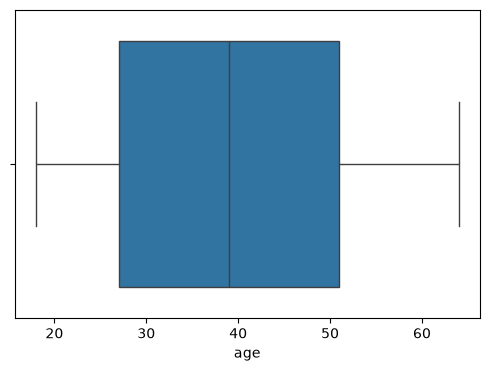

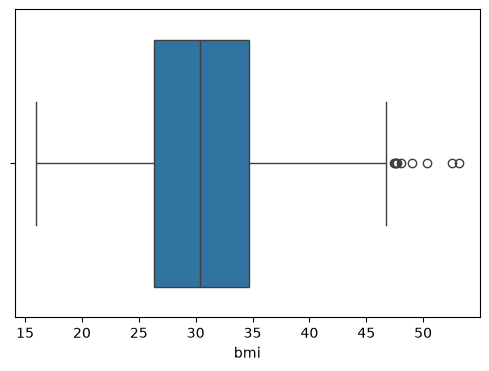

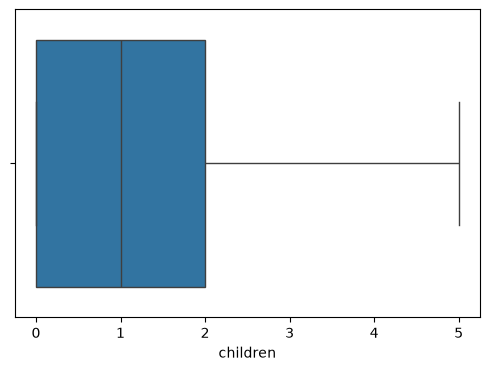

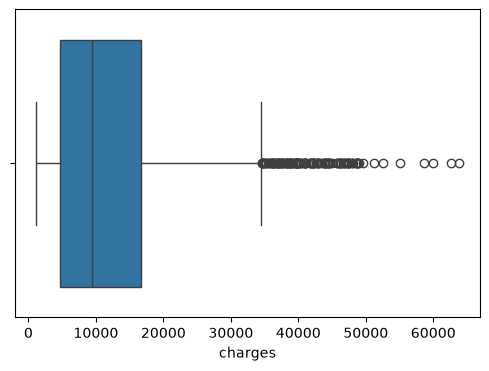

In [105]:
# Plotting Boxplots for Spotting Outliers

for col in numeric_col:
    plt.figure(figsize=(6,4))
    sns.boxplot(x= data[col])

<Axes: >

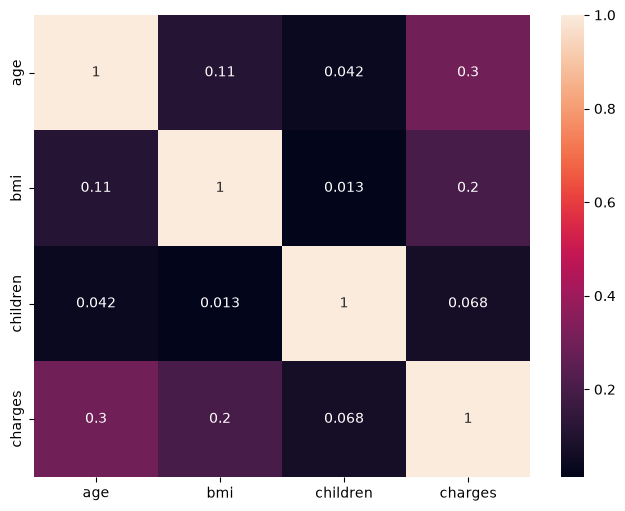

In [106]:
# Plotting Correlation with Heatmap

plt.figure(figsize=(8,6))
sns.heatmap(data.corr(numeric_only=True), annot= True)

# Data Cleaning and Preprocessing

In [107]:
data_cleaned = data.copy()

In [108]:
data_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [109]:
data_cleaned.shape

(1338, 7)

In [110]:
data_cleaned.drop_duplicates(inplace= True)

In [111]:
data_cleaned.shape

(1337, 7)

In [112]:
data_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [113]:
data_cleaned.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [114]:
data_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [115]:
data_cleaned['sex'] = data_cleaned['sex'].map({'male': 0, 'female': 1}) # Label Encoding 

In [116]:
data_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [117]:
data_cleaned['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [118]:
data_cleaned['smoker'] = data_cleaned['smoker'].map({'no': 0, 'yes': 1}) # Label Encoding 

In [119]:
data_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [120]:
# Renaming Columns

data_cleaned.rename( columns = {
    'sex': 'is_female',
    'smoker': 'is_smoker'
}, inplace= True)

data_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [121]:
data_cleaned['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [122]:
data_cleaned = pd.get_dummies(data_cleaned,columns= ['region'], drop_first=True, dtype= int)
data_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,0,0,1
1,18,0,33.770,1,0,1725.55230,0,1,0
2,28,0,33.000,3,0,4449.46200,0,1,0
3,33,0,22.705,0,0,21984.47061,1,0,0
4,32,0,28.880,0,0,3866.85520,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,1,0,0
1334,18,1,31.920,0,0,2205.98080,0,0,0
1335,18,1,36.850,0,0,1629.83350,0,1,0
1336,21,1,25.800,0,0,2007.94500,0,0,1


<Axes: >

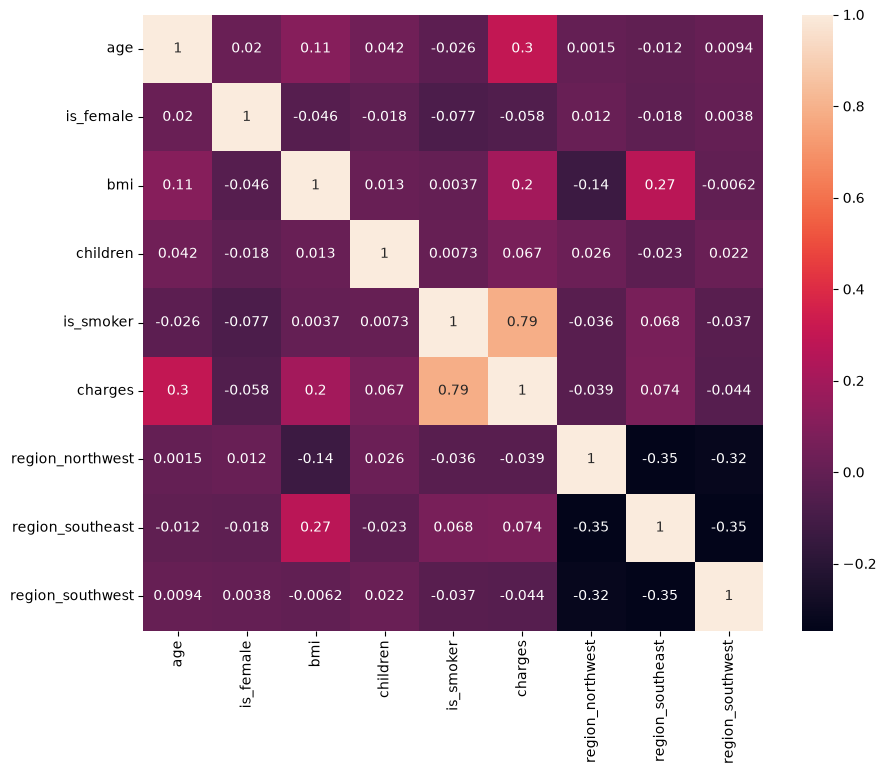

In [123]:
# Plotting Heatmap to see final correlation

plt.figure(figsize=(10,8))
sns.heatmap(data_cleaned.corr(), annot=True)

# Feature Engineering (Feature Selection and Feature Extraction)

<Axes: xlabel='bmi', ylabel='Count'>

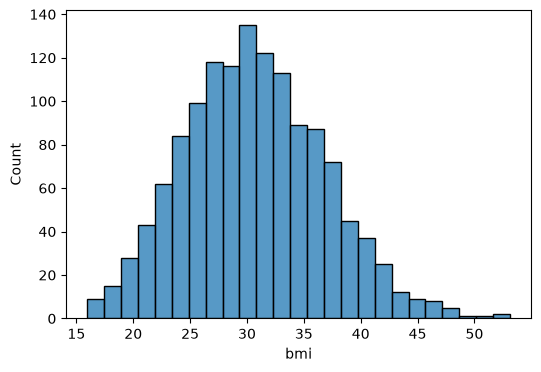

In [124]:
plt.figure(figsize=(6,4))
sns.histplot(x = data_cleaned['bmi'])

In [125]:
data_cleaned['bmi_category'] = pd.cut(
    x = data_cleaned['bmi'],
    bins = [0,18.5,24.9,29.9, float('inf')],
    labels = ['Underweight', 'Normal', 'Overweight', 'Obesity']
)

data_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27.900,0,1,16884.92400,0,0,1,Overweight
1,18,0,33.770,1,0,1725.55230,0,1,0,Obesity
2,28,0,33.000,3,0,4449.46200,0,1,0,Obesity
3,33,0,22.705,0,0,21984.47061,1,0,0,Normal
4,32,0,28.880,0,0,3866.85520,1,0,0,Overweight


In [126]:
data_cleaned = pd.get_dummies(data_cleaned, columns=['bmi_category'], drop_first=True, dtype=int)
data_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obesity
0,19,1,27.900,0,1,16884.92400,0,0,1,0,1,0
1,18,0,33.770,1,0,1725.55230,0,1,0,0,0,1
2,28,0,33.000,3,0,4449.46200,0,1,0,0,0,1
3,33,0,22.705,0,0,21984.47061,1,0,0,1,0,0
4,32,0,28.880,0,0,3866.85520,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,1,0,0,0,0,1
1334,18,1,31.920,0,0,2205.98080,0,0,0,0,0,1
1335,18,1,36.850,0,0,1629.83350,0,1,0,0,0,1
1336,21,1,25.800,0,0,2007.94500,0,0,1,0,1,0


In [127]:
data_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight',
       'bmi_category_Obesity'],
      dtype='str')

In [128]:
from sklearn.preprocessing import StandardScaler

In [129]:
# Scaling input features

cols = ['age', 'bmi', 'children']
scaler = StandardScaler()

data_cleaned[cols] = scaler.fit_transform(data_cleaned[cols])
data_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obesity
0,-1.440418,1,-0.453160,-0.909234,1,16884.92400,0,0,1,0,1,0
1,-1.511647,0,0.509422,-0.079442,0,1725.55230,0,1,0,0,0,1
2,-0.799350,0,0.383155,1.580143,0,4449.46200,0,1,0,0,0,1
3,-0.443201,0,-1.305052,-0.909234,0,21984.47061,1,0,0,1,0,0
4,-0.514431,0,-0.292456,-0.909234,0,3866.85520,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,0.050269,1.580143,0,10600.54830,1,0,0,0,0,1
1334,-1.511647,1,0.206053,-0.909234,0,2205.98080,0,0,0,0,0,1
1335,-1.511647,1,1.014490,-0.909234,0,1629.83350,0,1,0,0,0,1
1336,-1.297958,1,-0.797524,-0.909234,0,2007.94500,0,0,1,0,1,0


In [130]:
import statsmodels.api as sm

# Features X and Target y
X = data_cleaned.drop(columns=['charges'])
y = data_cleaned['charges']

X_with_constant = sm.add_constant(X)

# OLS (Ordinary Least Squares)
ols_model = sm.OLS(y, X_with_constant).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.755
Model:                            OLS   Adj. R-squared:                  0.753
Method:                 Least Squares   F-statistic:                     371.4
Date:                Tue, 28 Jul 2026   Prob (F-statistic):               0.00
Time:                        21:47:11   Log-Likelihood:                -13526.
No. Observations:                1337   AIC:                         2.708e+04
Df Residuals:                    1325   BIC:                         2.714e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    6

In [131]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range (len(X.columns))]

print (vif_data)

                    Feature       VIF
0                       age  1.017420
1                 is_female  1.965002
2                       bmi  3.142247
3                  children  1.004634
4                 is_smoker  1.266038
5          region_northwest  1.981934
6          region_southeast  2.221937
7          region_southwest  1.994540
8       bmi_category_Normal  2.419576
9   bmi_category_Overweight  2.350926
10     bmi_category_Obesity  4.488775


In [135]:
# Selected Features

selected_features = [
        'age', 'bmi', 'children', 'is_smoker', 
        'bmi_category_Obesity'
    ]

In [133]:
X_final = data_cleaned[selected_features]
y = data_cleaned['charges']
  
X_final_const = sm.add_constant(X_final)
final_model = sm.OLS(y, X_final_const).fit()
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.754
Model:                            OLS   Adj. R-squared:                  0.753
Method:                 Least Squares   F-statistic:                     815.9
Date:                Tue, 28 Jul 2026   Prob (F-statistic):               0.00
Time:                        21:47:11   Log-Likelihood:                -13529.
No. Observations:                1337   AIC:                         2.707e+04
Df Residuals:                    1331   BIC:                         2.710e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 6956.5604 

In [136]:
# New Column with Smoker and Obesity
data_cleaned['smoker_obese_interaction'] = data_cleaned['is_smoker'] * data_cleaned['bmi_category_Obesity']
  
# New selected features
final_features = [
        'age', 'bmi', 'children', 'is_smoker', 
        'bmi_category_Obesity', 'smoker_obese_interaction'
]
  
X_interaction = data_cleaned[final_features]
X_interaction_const = sm.add_constant(X_interaction)
  
interaction_model = sm.OLS(y, X_interaction_const).fit()
print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.859
Model:                            OLS   Adj. R-squared:                  0.858
Method:                 Least Squares   F-statistic:                     1349.
Date:                Tue, 28 Jul 2026   Prob (F-statistic):               0.00
Time:                        21:49:06   Log-Likelihood:                -13158.
No. Observations:                1337   AIC:                         2.633e+04
Df Residuals:                    1330   BIC:                         2.637e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [137]:
# Saving Cleaned CSV

final_columns = final_features + ['charges']
final_csv_to_save = data_cleaned[final_columns]

final_csv_to_save.to_csv('insurance_cleaned.csv', index=False)